In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df = pd.read_csv('spam.csv', encoding ='latin1')

In [4]:
df.head(5)

,v1,v2,Unnamed: 2,Unnamed: 3,Unnamed: 4
0,ham,"Go until jurong point, crazy.. Available only ...",NaN,NaN,NaN
1,ham,Ok lar... Joking wif u oni...,NaN,NaN,NaN
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,NaN,NaN,NaN
3,ham,U dun say so early hor... U c already then say...,NaN,NaN,NaN
4,ham,"Nah I don't think he goes to usf, he lives aro...",NaN,NaN,NaN


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5572 entries, 0 to 5571
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   v1          5572 non-null   object
 1   v2          5572 non-null   object
 2   Unnamed: 2  50 non-null     object
 3   Unnamed: 3  12 non-null     object
 4   Unnamed: 4  6 non-null      object
dtypes: object(5)
memory usage: 217.8+ KB


In [6]:
df.drop(columns=['Unnamed: 2','Unnamed: 3','Unnamed: 4'], inplace = True)

In [7]:
df.head(5)

,v1,v2
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


In [8]:
df.rename(columns={'v1':'target','v2':'text'},inplace = True)

In [9]:
df.duplicated().sum()

np.int64(403)

In [10]:
df.drop_duplicates(inplace=True)

In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 5169 entries, 0 to 5571
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   target  5169 non-null   object
 1   text    5169 non-null   object
dtypes: object(2)
memory usage: 121.1+ KB


In [12]:
from sklearn.preprocessing import LabelEncoder

In [13]:
le = LabelEncoder()
df['target'] = le.fit_transform(df['target'])

In [14]:
df.head(5)

,target,text
0,0,"Go until jurong point, crazy.. Available only ..."
1,0,Ok lar... Joking wif u oni...
2,1,Free entry in 2 a wkly comp to win FA Cup fina...
3,0,U dun say so early hor... U c already then say...
4,0,"Nah I don't think he goes to usf, he lives aro..."


In [15]:
df.target.value_counts()


target
0    4516
1     653
Name: count, dtype: int64

In [16]:
pip install nltk

Note: you may need to restart the kernel to use updated packages.


In [17]:
import nltk
nltk.download('punkt')
nltk.download('punkt_tab')

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\Lenovo\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\Lenovo\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


True

In [18]:
df['num_char']= df['text'].apply(len)

In [19]:
df['num_words']=df['text'].apply(lambda x : len(nltk.word_tokenize(x)))

In [20]:
df['num_sentence']=df['text'].apply(lambda x : len(nltk.sent_tokenize(x)))

<Axes: xlabel='num_words', ylabel='Count'>

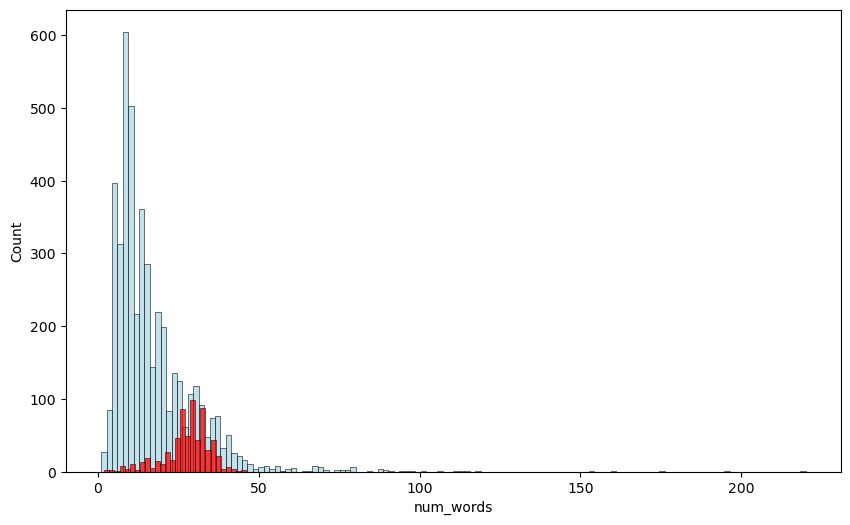

In [21]:
plt.figure(figsize=(10,6))
sns.histplot(df[df['target']==0]['num_words'],color = 'lightblue')
sns.histplot(df[df['target']==1]['num_words'],color = 'r')

<Axes: >

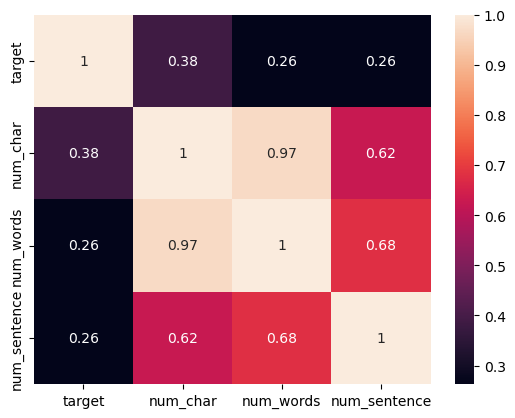

In [22]:
sns.heatmap(df.corr(numeric_only = True),annot = True)

## Text Preprocessing
1. lowercase conversion
2. tokenisation
3. special character remove
4. remove stopword
5. stemming
   

In [23]:
nltk.download('stopwords')
from nltk.corpus import stopwords
from nltk.stem.porter import PorterStemmer
ps = PorterStemmer()

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\Lenovo\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [24]:
def transform_text(text):
    text = text.lower()
    text = nltk.word_tokenize(text)
    cleaned_text = []
    for i in text:
        if i.isalnum() and i not in stopwords.words('english'):
            cleaned_text.append(ps.stem(i))
    return " ".join(cleaned_text)

In [25]:
transform_text('hi my how are you name going behind walking machine learning is in DIsha&&')

'hi name go behind walk machin learn disha'

In [26]:
df['transformed_text'] = df['text'].apply(transform_text)

In [27]:
df.head(5)

,target,text,num_char,num_words,num_sentence,transformed_text
0,0,"Go until jurong point, crazy.. Available only ...",111,24,2,go jurong point crazi avail bugi n great world...
1,0,Ok lar... Joking wif u oni...,29,8,2,ok lar joke wif u oni
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155,37,2,free entri 2 wkli comp win fa cup final tkt 21...
3,0,U dun say so early hor... U c already then say...,49,13,1,u dun say earli hor u c alreadi say
4,0,"Nah I don't think he goes to usf, he lives aro...",61,15,1,nah think goe usf live around though


In [28]:
!pip install wordcloud
from wordcloud import WordCloud

In [29]:
from wordcloud import WordCloud
wc = WordCloud(width=400,height=200,min_font_size =4,background_color='white')

In [30]:
spam_wc = wc.generate(df[df['target']== 1]['transformed_text'].str.cat(sep=" "))

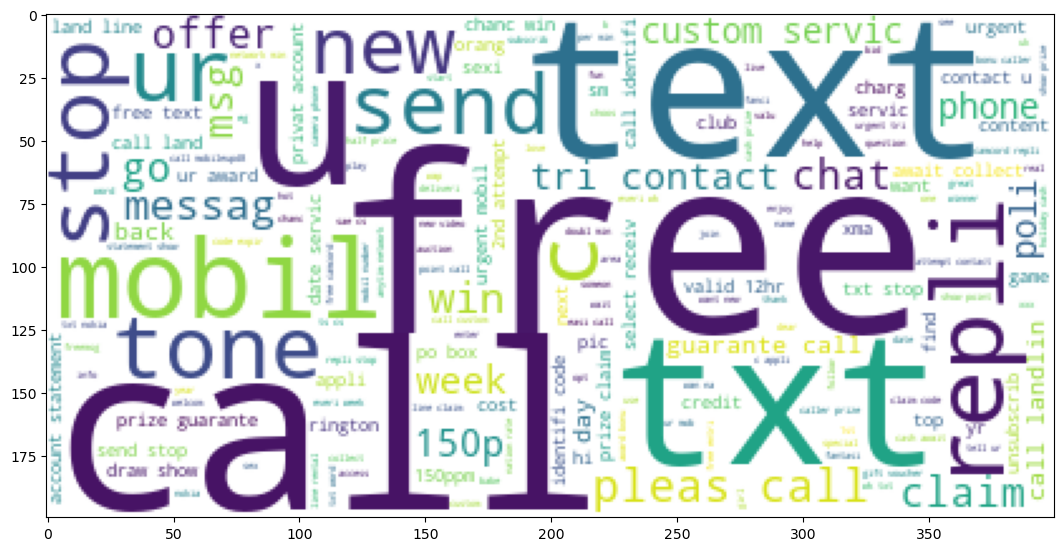

In [31]:
plt.figure(figsize = (13,8))
plt.imshow(spam_wc)

In [32]:
ham_wc = wc.generate(df[df['target']== 0]['transformed_text'].str.cat(sep=" "))

plt.figure(figsize=(10,8))
plt.imshow(ham_wc)

In [33]:
spam_corpus = []
for msg in df[df['target']==1]['transformed_text'].to_list():
    for word in msg.split():
        spam_corpus.append(word)

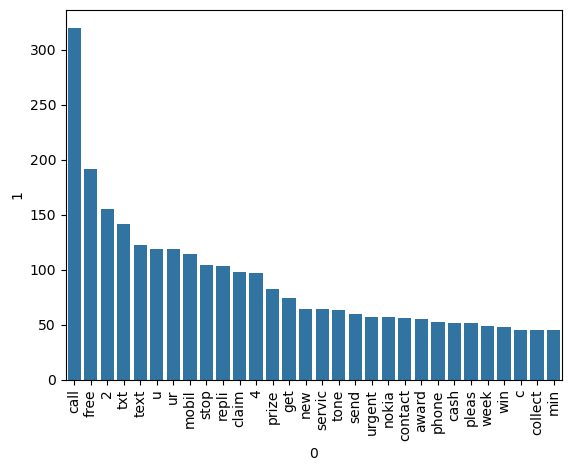

In [34]:
from collections import Counter
sns.barplot(x= pd.DataFrame(Counter(spam_corpus).most_common(30))[0],y = pd.DataFrame(Counter(spam_corpus).most_common(30))[1])
plt.xticks(rotation ='vertical')
plt.show()           


In [35]:
ham_corpus = []
for msg in df[df['target']==0]['transformed_text'].to_list():
    for word in msg.split():
        ham_corpus.append(word)
    

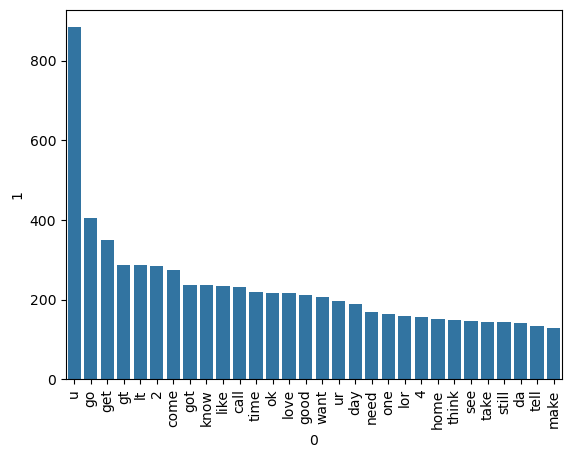

In [36]:
from collections import Counter
sns.barplot(x= pd.DataFrame(Counter(ham_corpus).most_common(30))[0],y = pd.DataFrame(Counter(ham_corpus).most_common(30))[1])
plt.xticks(rotation ='vertical')
plt.show()           


In [37]:
len(spam_corpus)

9939

In [38]:
len(ham_corpus)

35404

# Text vectorization using bag of words


In [39]:
df.head()

,target,text,num_char,num_words,num_sentence,transformed_text
0,0,"Go until jurong point, crazy.. Available only ...",111,24,2,go jurong point crazi avail bugi n great world...
1,0,Ok lar... Joking wif u oni...,29,8,2,ok lar joke wif u oni
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155,37,2,free entri 2 wkli comp win fa cup final tkt 21...
3,0,U dun say so early hor... U c already then say...,49,13,1,u dun say earli hor u c alreadi say
4,0,"Nah I don't think he goes to usf, he lives aro...",61,15,1,nah think goe usf live around though


## Model building

In [40]:
from sklearn.feature_extraction.text import CountVectorizer,TfidfVectorizer
cv = CountVectorizer()
tfidf = TfidfVectorizer(max_features= 3000)

In [41]:
x = tfidf.fit_transform(df['transformed_text']).toarray()

In [42]:
x.shape

(5169, 3000)

In [43]:
y = df['target'].values

In [44]:
from sklearn.model_selection import train_test_split
x_train, x_test, y_train,y_test = train_test_split(x,y, test_size =0.2, random_state = 42) 

In [45]:
from sklearn.naive_bayes import GaussianNB, MultinomialNB,BernoulliNB
from sklearn.metrics import accuracy_score,classification_report,confusion_matrix,precision_score
gb = GaussianNB()
mb = MultinomialNB()
bb = BernoulliNB()

In [46]:
gb.fit(x_train,y_train)
ypred = gb.predict(x_test)
print(accuracy_score(y_test,ypred))
print(classification_report(y_test,ypred))
print(confusion_matrix(y_test,ypred))

0.8626692456479691
              precision    recall  f1-score   support

           0       0.97      0.87      0.92       889
           1       0.51      0.83      0.63       145

    accuracy                           0.86      1034
   macro avg       0.74      0.85      0.77      1034
weighted avg       0.90      0.86      0.88      1034

[[771 118]
 [ 24 121]]


In [47]:
mb.fit(x_train,y_train)
ypred2 = mb.predict(x_test)
print(accuracy_score(y_test,ypred2))
print(classification_report(y_test,ypred2))
print(confusion_matrix(y_test,ypred2))

0.9729206963249516
              precision    recall  f1-score   support

           0       0.97      1.00      0.98       889
           1       0.99      0.81      0.89       145

    accuracy                           0.97      1034
   macro avg       0.98      0.91      0.94      1034
weighted avg       0.97      0.97      0.97      1034

[[888   1]
 [ 27 118]]


In [48]:
bb.fit(x_train,y_train)
ypred3 = bb.predict(x_test)
print(accuracy_score(y_test,ypred3))
print(classification_report(y_test,ypred3))
print(confusion_matrix(y_test,ypred3))

0.9729206963249516
              precision    recall  f1-score   support

           0       0.97      0.99      0.98       889
           1       0.96      0.84      0.90       145

    accuracy                           0.97      1034
   macro avg       0.97      0.92      0.94      1034
weighted avg       0.97      0.97      0.97      1034

[[884   5]
 [ 23 122]]


In [49]:
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import MultinomialNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import AdaBoostClassifier
from sklearn.ensemble import GradientBoostingClassifier


In [50]:
svc = SVC()
lr = LogisticRegression()
knn = KNeighborsClassifier()
Mb = MultinomialNB()
dt = DecisionTreeClassifier()
rfc = RandomForestClassifier()
abc = AdaBoostClassifier()
gbc = GradientBoostingClassifier()

In [51]:
clfs ={'SVC' :svc , 'LR': lr ,'KNN': knn ,'MB': Mb ,'DT':dt ,'RFC':rfc ,'ABC':abc ,'GBC':gbc }

In [52]:
def train_classifier(clf, x_train, y_train, x_test,y_test):
    clf.fit(x_train, y_train)
    y_pred= clf.predict(x_test)
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)

    return accuracy,precision

In [53]:
train_classifier(svc,x_train,y_train,x_test,y_test)

(0.9748549323017408, 0.9917355371900827)

In [54]:
accuracy_scores = []
precision_scores =[]

for name,clf in clfs.items():
    current_accuracy,current_precision= train_classifier(clf,x_train,y_train,x_test,y_test)

    print('For', name)
    print('accuracy_score -',current_accuracy )
    print('precision_score -',current_precision )
    accuracy_scores.append(current_accuracy)
    precision_scores.append(current_precision)

For SVC
accuracy_score - 0.9748549323017408
precision_score - 0.9917355371900827
For LR
accuracy_score - 0.9584139264990329
precision_score - 0.9473684210526315


C:\Users\Lenovo\anaconda3\Lib\site-packages\joblib\externals\loky\backend\context.py:136: UserWarning: Could not find the number of physical cores for the following reason:
[WinError 2] The system cannot find the file specified
Returning the number of logical cores instead. You can silence this warning by setting LOKY_MAX_CPU_COUNT to the number of cores you want to use.
  warnings.warn(
  File "C:\Users\Lenovo\anaconda3\Lib\site-packages\joblib\externals\loky\backend\context.py", line 257, in _count_physical_cores
    cpu_info = subprocess.run(
        "wmic CPU Get NumberOfCores /Format:csv".split(),
        capture_output=True,
        text=True,
    )
  File "C:\Users\Lenovo\anaconda3\Lib\subprocess.py", line 554, in run
    with Popen(*popenargs, **kwargs) as process:
         ~~~~~^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\Lenovo\anaconda3\Lib\subprocess.py", line 1039, in __init__
    self._execute_child(args, executable, preexec_fn, close_fds,
    ~~~~~~~~~~~~~~~~~~~^^^^^^^^^^^^^^

For KNN
accuracy_score - 0.9061895551257253
precision_score - 1.0
For MB
accuracy_score - 0.9729206963249516
precision_score - 0.9915966386554622
For DT
accuracy_score - 0.9506769825918762
precision_score - 0.8263888888888888
For RFC
accuracy_score - 0.9738878143133463
precision_score - 0.9916666666666667
For ABC
accuracy_score - 0.913926499032882
precision_score - 0.7916666666666666
For GBC
accuracy_score - 0.9632495164410058
precision_score - 0.9652173913043478


In [55]:
Predicted_score = pd.DataFrame({'Algorithm':clfs.keys(),'Accuracy':accuracy_scores, 'Precision':precision_scores}).sort_values('Precision',ascending =False)

In [56]:
Predicted_score

,Algorithm,Accuracy,Precision
2,KNN,0.906190,1.000000
0,SVC,0.974855,0.991736
5,RFC,0.973888,0.991667
3,MB,0.972921,0.991597
7,GBC,0.963250,0.965217
1,LR,0.958414,0.947368
4,DT,0.950677,0.826389
6,ABC,0.913926,0.791667


In [57]:
import pickle
pickle.dump(tfidf,open('vectorizer.pkl','wb'))
pickle.dump(Mb,open('model.pkl','wb'))